# 06 — Divergência humano × juízes-LLM, segmentado por origem da coleta

**Pergunta deste notebook:** *quando ChatGPT-juiz e Claude-juiz divergem e um humano arbitra, o padrão de divergência muda dependendo de a resposta ter vindo de uma chamada de **API instrumentada** (`ferramenta`) ou de uma sessão de **chat comercial** (`chat_comercial`)?*

Este notebook **complementa** o `05_sintese.ipynb` — não substitui. Lê o mesmo `result_unificado_final.xlsx` e adiciona um corte que o `05_sintese` não exibe: **chat × api**.

Convenção:
- `origem_resultado == "ferramenta"` → **API** (chamada instrumentada, com custo e latência reais)
- `origem_resultado == "chat_comercial"` → **CHAT** (sessão na interface web, sem custo nem latência medidos)

Pelas regras combinadas, o custo do chat é tratado como **0,00 USD** para fins de comparação visual; a latência permanece **não medida** e os gráficos que dependem dela mostram só a faixa API.

Estrutura:

1. **Carregamento e definição do corte** — quantas respostas em cada origem
2. **Geral** — divergência agregada, estilo `avaliacao_1.ipynb`
3. **Só CHAT** — recorte das respostas de interface web (`std_chatgpt`, `std_claude`)
4. **Só API** — recorte das respostas instrumentadas (9 modelos)
5. **Comparativo lado-a-lado CHAT × API** — onde o padrão muda
6. **Concordância humano vs cada juiz-LLM** — extra que o avaliacao_1 não tinha (`avaliacao_humana` aqui está preenchida em todas as linhas, não só nos divergentes)

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Reaproveita o mesmo carregador do 05_sintese.ipynb (resolve o caminho do xlsx
# do mesmo jeito que os outros notebooks do projeto). Se nao existir, faz fallback.
try:
    from utils import carregar_dados, estilo_padrao
    estilo_padrao()
    df = carregar_dados()
except Exception as e:
    print(f"(fallback) nao usei utils.carregar_dados ({type(e).__name__}: {e})")
    from pathlib import Path
    candidatos = [
        Path("result_unificado_final.xlsx"),
        Path("../result_unificado_final.xlsx"),
        Path("../../result_unificado_final.xlsx"),
        Path("data/result_unificado_final.xlsx"),
        Path("../data/result_unificado_final.xlsx"),
    ]
    PATH = next((p for p in candidatos if p.exists()), None)
    if PATH is None:
        raise FileNotFoundError(
            "Nao encontrei result_unificado_final.xlsx. "
            "Defina PATH manualmente: PATH = Path('/caminho/para/result_unificado_final.xlsx')"
        )
    df = pd.read_excel(PATH)

    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 150,
        "font.size": 10, "axes.titleweight": "bold", "axes.titlesize": 12,
    })

PALETA_AVALIADOR = {"gpt": "#10A37F", "opus": "#D97757", "humano": "#8E44AD"}
PALETA_ORIGEM    = {"chat": "#5DADE2", "api":  "#E67E22"}
CORES_NOTA       = {0.0: "#E74C3C", 0.5: "#F39C12", 1.0: "#2ECC71"}

print(f"df carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

# Garantia de dtype: chats tem string "nao pertinente" em custo/latencia, o que
# faz a coluna virar object e quebrar agregacoes. Converter para numerico.
for col in ["custo_estimado_usd", "latencia_s",
            "avaliacao_final", "avaliacao_gpt", "avaliacao_opus",
            "n_invocacoes", "input_tokens", "output_tokens",
            "resposta_tokens_tiktoken", "concisao_score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Dtypes apos limpeza: custo={df['custo_estimado_usd'].dtype}, "
      f"latencia={df['latencia_s'].dtype}, final={df['avaliacao_final'].dtype}")

df carregado: 1650 linhas x 28 colunas
Dtypes apos limpeza: custo=float64, latencia=float64, final=float64


## 1. Definição do corte: Chat vs API

O xlsx já traz `origem_resultado` ∈ {`ferramenta`, `chat_comercial`}. Crio dois auxiliares:

- `origem` ∈ {`chat`, `api`} — versão curta
- `custo_norm` — `custo_estimado_usd` para `api`, **0,00** para `chat` (combinado: chat sem custo medido)

A latência continua `NaN` para os chats — não medimos.

In [2]:
df["origem"] = np.where(df["origem_resultado"] == "chat_comercial", "chat", "api")
df["custo_norm"] = np.where(df["origem"] == "chat", 0.0, df["custo_estimado_usd"])

# avaliacao_final pode chegar como object por causa de "nao pertinente" em algumas planilhas
# Aqui é numérico, mas garantimos:
df["avaliacao_final"] = pd.to_numeric(df["avaliacao_final"], errors="coerce")
# avaliacao_humana tem string "nao pertinente" — manter como object e filtrar quando precisar
df["av_humana_num"] = pd.to_numeric(df["avaliacao_humana"], errors="coerce")

resumo = (df.groupby("origem")
            .agg(n_linhas        = ("avaliacao_final", "size"),
                 n_modelos       = ("modelo",          "nunique"),
                 n_divergentes   = ("convergencia",    lambda s: (~s).sum()),
                 precisao_media  = ("avaliacao_final", "mean"),
                 custo_medio_usd = ("custo_norm",      "mean"),
                 latencia_mediana= ("latencia_s",      "median")))
resumo["taxa_divergencia"] = resumo["n_divergentes"] / resumo["n_linhas"]
resumo.round(4)

,n_linhas,n_modelos,n_divergentes,precisao_media,custo_medio_usd,latencia_mediana,taxa_divergencia
origem,,,,,,,
api,1350,9,92,0.9552,0.0323,9.525,0.0681
chat,300,2,29,0.9133,0.0000,NaN,0.0967


**Como ler:** `taxa_divergencia` é a fração das respostas daquela origem em que ChatGPT-juiz e Claude-juiz discordaram (e portanto entraram em arbitragem). Latência mediana fica `NaN` para o chat — apenas confirma que não temos medida.

Observe que **API tem 9 modelos × 150 linhas = 1.350**, enquanto **CHAT tem 2 modelos × 150 linhas = 300**. O CHAT é uma amostra muito menor — leituras de proporção são mais ruidosas lá.

## 2. Visão geral — todas as origens

Painel 1×2 no estilo do `avaliacao_1.ipynb`: à esquerda a distribuição de notas dos três avaliadores nos casos divergentes; à direita, em quem o humano confiou.

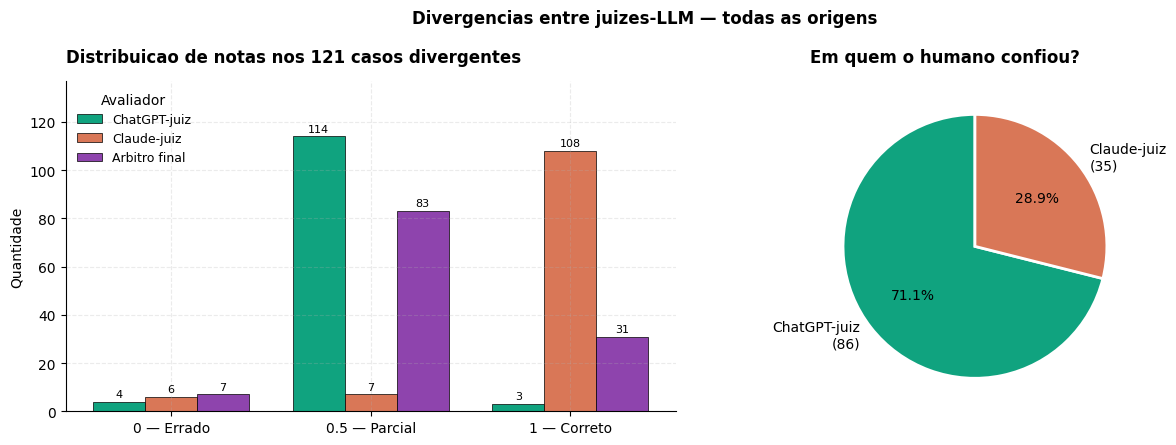


Total de divergencias: 121  (em 1650 respostas, 7.3%)
Humano concordou com ChatGPT-juiz:   86  (71.1%)
Humano concordou com Claude-juiz:    35  (28.9%)


In [3]:
def painel_divergencia(d, titulo_extra=""):
    """Painel 1x2: (esq) distribuicao de notas dos juizes nos divergentes,
    (dir) em quem o humano confiou. Estilo do avaliacao_1.ipynb."""
    div = d[~d["convergencia"]].copy()
    n = len(div)
    if n == 0:
        print(f"Sem divergencias em {titulo_extra}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # ── esquerda: 3 avaliadores nos divergentes ──
    notas = [0.0, 0.5, 1.0]
    x = np.arange(len(notas))
    w = 0.26
    cols_av = {
        "ChatGPT-juiz":   ("avaliacao_gpt",   PALETA_AVALIADOR["gpt"]),
        "Claude-juiz":    ("avaliacao_opus",  PALETA_AVALIADOR["opus"]),
        "Arbitro final":  ("avaliacao_final", PALETA_AVALIADOR["humano"]),
    }
    ymax_obs = 0
    for i, (label, (col, cor)) in enumerate(cols_av.items()):
        cnt = div[col].value_counts().reindex(notas, fill_value=0)
        ymax_obs = max(ymax_obs, cnt.max())
        bars = axes[0].bar(x + (i - 1) * w, cnt.values, w,
                           label=label, color=cor,
                           edgecolor="black", linewidth=0.5)
        for bar, v in zip(bars, cnt.values):
            if v > 0:
                axes[0].text(bar.get_x() + bar.get_width()/2, v + max(ymax_obs*0.01, 0.3),
                             str(int(v)), ha="center", va="bottom", fontsize=8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(["0 — Errado", "0.5 — Parcial", "1 — Correto"])
    axes[0].set_ylabel("Quantidade")
    axes[0].set_title(f"Distribuicao de notas nos {n} casos divergentes")
    axes[0].legend(title="Avaliador", fontsize=9)
    axes[0].set_ylim(0, max(1, ymax_obs) * 1.20)

    # ── direita: em quem o humano confiou (entre os divergentes pertinentes) ──
    div_num = div[div["av_humana_num"].notna()].copy()
    div_num["confiou_em"] = np.where(
        div_num["av_humana_num"] == div_num["avaliacao_gpt"], "gpt",
        np.where(div_num["av_humana_num"] == div_num["avaliacao_opus"], "opus", "nenhum"))
    razao = div_num["confiou_em"].value_counts()
    label_map = {"gpt": "ChatGPT-juiz", "opus": "Claude-juiz", "nenhum": "Discordou de ambos"}
    cor_map   = {"gpt":  PALETA_AVALIADOR["gpt"],
                 "opus": PALETA_AVALIADOR["opus"],
                 "nenhum": "#95A5A6"}
    if len(razao):
        labels_pie = [f"{label_map[k]}\n({v})" for k, v in razao.items()]
        cores_r    = [cor_map[k] for k in razao.index]
        axes[1].pie(razao.values, labels=labels_pie,
                    colors=cores_r, autopct="%1.1f%%", startangle=90,
                    wedgeprops={"edgecolor": "white", "linewidth": 2})
        axes[1].set_title("Em quem o humano confiou?")
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "Sem nota humana pertinente\nentre os divergentes",
                     ha="center", va="center", fontsize=11)

    nao_pert = len(div) - len(div_num)
    sup = f"Divergencias entre juizes-LLM — {titulo_extra}" if titulo_extra else "Divergencias entre juizes-LLM"
    fig.suptitle(sup, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\nTotal de divergencias: {n}  (em {len(d)} respostas, {n/len(d):.1%})")
    if len(div_num):
        print(f"Humano concordou com ChatGPT-juiz:  {razao.get('gpt',  0):>3}  ({razao.get('gpt',  0)/len(div_num):.1%})")
        print(f"Humano concordou com Claude-juiz:   {razao.get('opus', 0):>3}  ({razao.get('opus', 0)/len(div_num):.1%})")
        if razao.get("nenhum", 0):
            print(f"Humano deu nota fora do menu dos juizes: {razao.get('nenhum', 0)}")
    if nao_pert:
        print(f"Divergentes marcados 'nao pertinente' pelo humano: {nao_pert}")

painel_divergencia(df, "todas as origens")

**Leitura:** este é o agregado — equivalente direto ao painel do `avaliacao_1.ipynb`. As próximas duas seções repetem **exatamente** este painel restringindo a origem da resposta.

## 3. Recorte: só respostas coletadas via Chat (`chat_comercial`)

Apenas 2 modelos aqui — `std_chatgpt` e `std_claude` —, com 150 linhas cada. Tamanho pequeno; padrões aqui são indicativos, não conclusivos.

Respostas Chat: 300  |  Modelos: ['std_chatgpt', 'std_claude']
Divergencias no Chat: 29


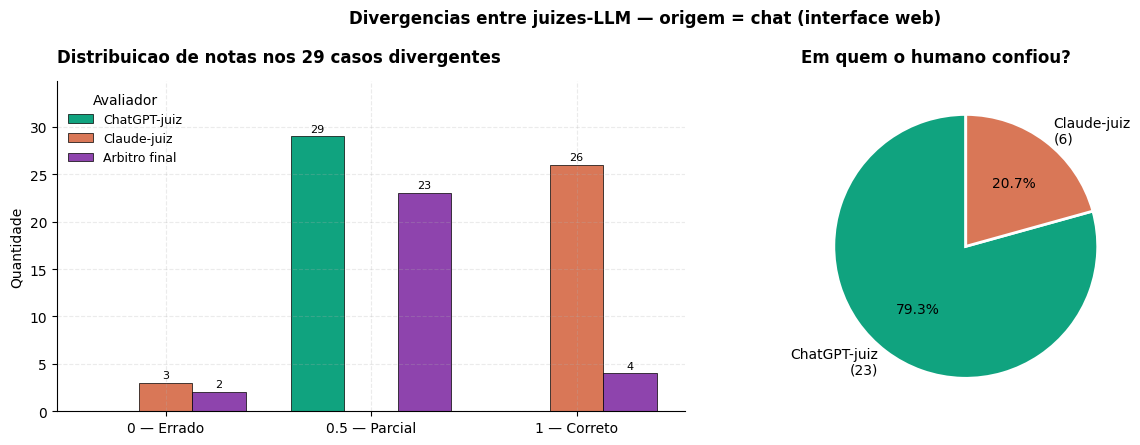


Total de divergencias: 29  (em 300 respostas, 9.7%)
Humano concordou com ChatGPT-juiz:   23  (79.3%)
Humano concordou com Claude-juiz:     6  (20.7%)


In [4]:
df_chat = df[df["origem"] == "chat"].copy()
print(f"Respostas Chat: {len(df_chat)}  |  Modelos: {sorted(df_chat['modelo'].unique())}")
print(f"Divergencias no Chat: {(~df_chat['convergencia']).sum()}")
painel_divergencia(df_chat, "origem = chat (interface web)")

**Padrão a observar:** se o humano confia mais em um juiz específico **só no recorte chat**, o juiz pode estar reagindo a artefatos da interface (markdown, citações, formatação livre) e não ao conteúdo. Compare com a seção 4.

## 4. Recorte: só respostas coletadas via API (`ferramenta`)

Respostas API: 1350  |  Modelos: 9
Modelos: ['claude-haiku-4-5', 'claude-opus-4-7', 'claude-sonnet-4-6', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gpt-4o-mini', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.5']
Divergencias na API: 92


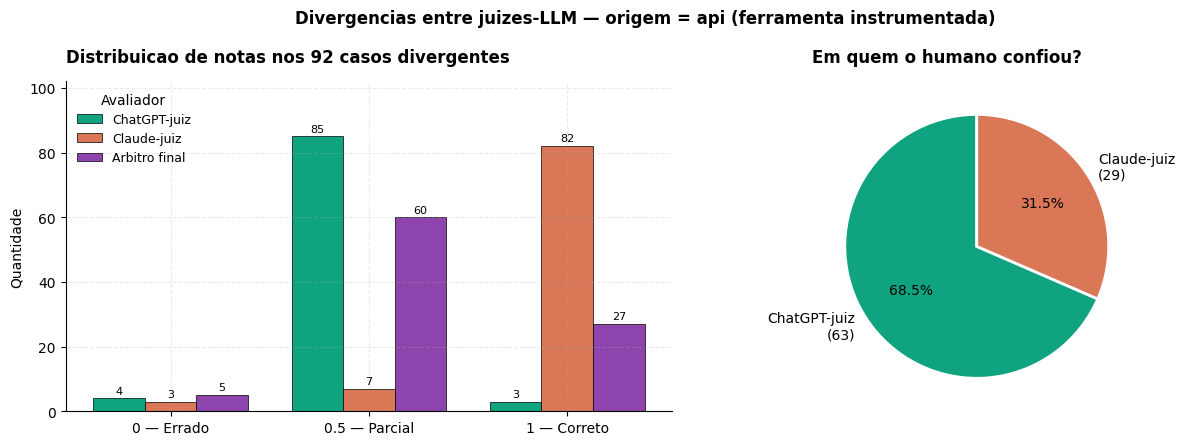


Total de divergencias: 92  (em 1350 respostas, 6.8%)
Humano concordou com ChatGPT-juiz:   63  (68.5%)
Humano concordou com Claude-juiz:    29  (31.5%)


In [5]:
df_api = df[df["origem"] == "api"].copy()
print(f"Respostas API: {len(df_api)}  |  Modelos: {df_api['modelo'].nunique()}")
print("Modelos:", sorted(df_api['modelo'].unique()))
print(f"Divergencias na API: {(~df_api['convergencia']).sum()}")
painel_divergencia(df_api, "origem = api (ferramenta instrumentada)")

**Padrão a observar:** respostas de API tendem a ser mais homogêneas estruturalmente (mesmo prompt, mesma `temperature`, mesmo formato de saída). Se a taxa de divergência cai aqui em relação ao chat, é evidência de que parte do ruído entre juízes vem da heterogeneidade do chat.

## 5. Comparativo Chat × API

Três visões lado a lado:

- **5.1** Taxa de divergência e voto humano por origem
- **5.2** Distribuição de notas nos divergentes, por origem
- **5.3** Severidade do juiz — quem é mais duro em cada canal?

### 5.1 Taxa de divergência e voto humano por origem

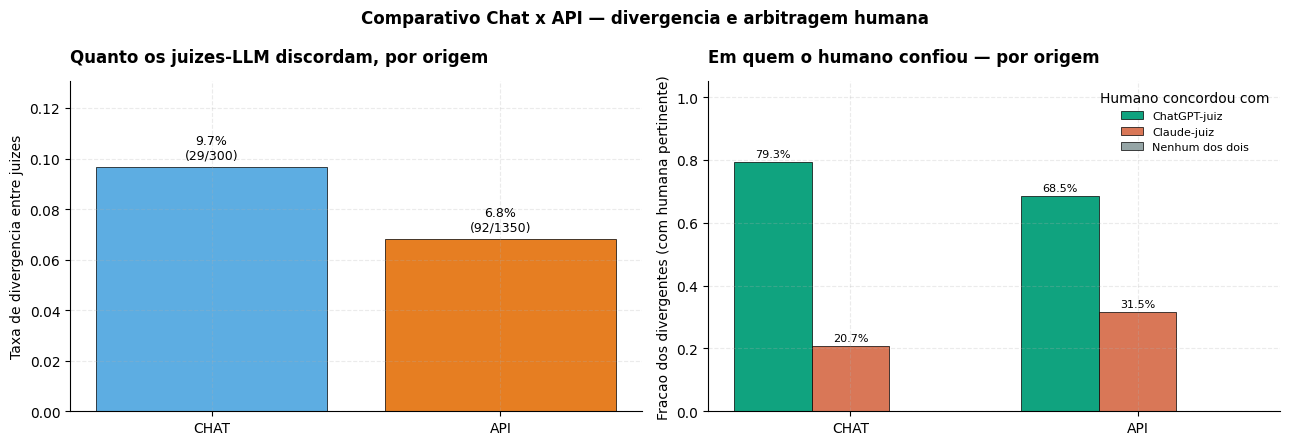

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── esq: taxa de divergencia por origem ──
taxas = []
for org in ["chat", "api"]:
    sub = df[df["origem"] == org]
    div_n = (~sub["convergencia"]).sum()
    taxas.append((org, div_n, len(sub), div_n / max(1, len(sub))))
td = pd.DataFrame(taxas, columns=["origem","divergentes","total","taxa"])

bars = axes[0].bar(td["origem"].str.upper(), td["taxa"],
                   color=[PALETA_ORIGEM[o] for o in td["origem"]],
                   edgecolor="black", linewidth=0.5)
for bar, row in zip(bars, td.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 row.taxa + max(td["taxa"].max()*0.02, 0.002),
                 f"{row.taxa:.1%}\n({row.divergentes}/{row.total})",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Taxa de divergencia entre juizes")
axes[0].set_title("Quanto os juizes-LLM discordam, por origem")
axes[0].set_ylim(0, max(td["taxa"].max() * 1.35, 0.05))

# ── dir: voto humano normalizado, por origem ──
votos_por_origem = {}
for org in ["chat","api"]:
    sub = df[(df["origem"] == org) & (~df["convergencia"]) & (df["av_humana_num"].notna())].copy()
    if len(sub):
        sub["confiou_em"] = np.where(sub["av_humana_num"] == sub["avaliacao_gpt"], "gpt",
                              np.where(sub["av_humana_num"] == sub["avaliacao_opus"], "opus", "nenhum"))
        votos_por_origem[org] = sub["confiou_em"].value_counts(normalize=True).reindex(
            ["gpt","opus","nenhum"], fill_value=0)
    else:
        votos_por_origem[org] = pd.Series([0,0,0], index=["gpt","opus","nenhum"])

x = np.arange(2)
w = 0.27
for i, (cat, cor, label) in enumerate([
    ("gpt",    PALETA_AVALIADOR["gpt"],  "ChatGPT-juiz"),
    ("opus",   PALETA_AVALIADOR["opus"], "Claude-juiz"),
    ("nenhum", "#95A5A6",                "Nenhum dos dois"),
]):
    vals = [votos_por_origem["chat"][cat], votos_por_origem["api"][cat]]
    bars = axes[1].bar(x + (i - 1) * w, vals, w,
                       label=label, color=cor,
                       edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if v > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                         f"{v:.1%}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["CHAT","API"])
axes[1].set_ylabel("Fracao dos divergentes (com humana pertinente)")
axes[1].set_title("Em quem o humano confiou — por origem")
axes[1].legend(title="Humano concordou com", fontsize=8, loc="upper right")
axes[1].set_ylim(0, 1.05)

plt.suptitle("Comparativo Chat x API — divergencia e arbitragem humana",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Como interpretar:**

- **Taxa de divergência maior em Chat** → mais ruído entre juízes no formato livre, provavelmente formatação e estilo que cada juiz pondera diferente.
- **Humano confia em juízes diferentes em cada canal** → viés condicional ao formato. Em produção, isso importaria: o juiz a usar dependeria do canal de coleta das respostas.

### 5.2 Distribuição das notas dos juízes nos divergentes, por origem

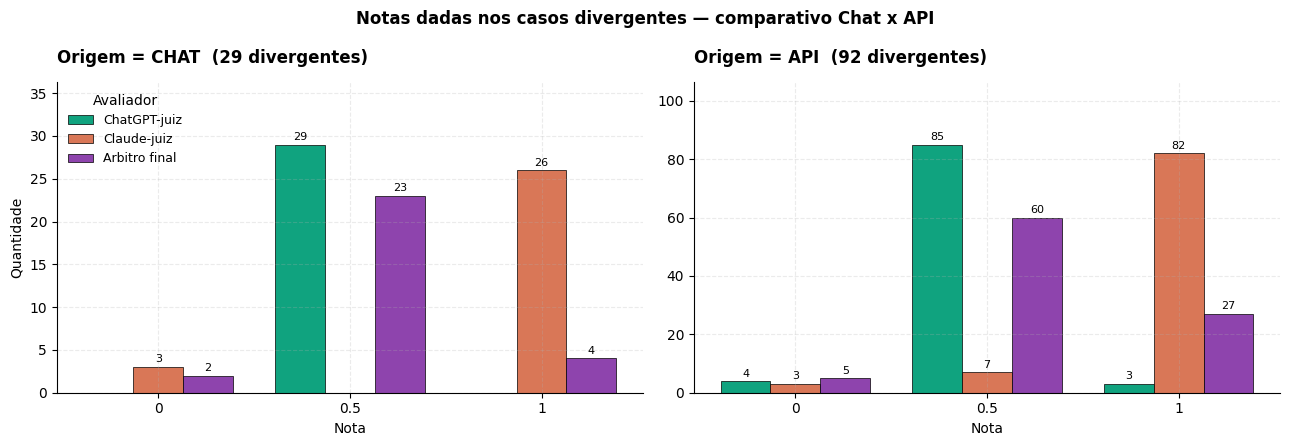

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, org in zip(axes, ["chat", "api"]):
    sub = df[(df["origem"] == org) & (~df["convergencia"])]
    notas = [0.0, 0.5, 1.0]
    x = np.arange(len(notas))
    w = 0.26
    cols_av = {
        "ChatGPT-juiz":   ("avaliacao_gpt",   PALETA_AVALIADOR["gpt"]),
        "Claude-juiz":    ("avaliacao_opus",  PALETA_AVALIADOR["opus"]),
        "Arbitro final":  ("avaliacao_final", PALETA_AVALIADOR["humano"]),
    }
    ymax_obs = 0
    for i, (label, (col, cor)) in enumerate(cols_av.items()):
        cnt = sub[col].value_counts().reindex(notas, fill_value=0)
        ymax_obs = max(ymax_obs, cnt.max())
        bars = ax.bar(x + (i - 1) * w, cnt.values, w,
                      label=label, color=cor,
                      edgecolor="black", linewidth=0.5)
        for bar, v in zip(bars, cnt.values):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, v + max(ymax_obs*0.01, 0.3),
                        str(int(v)), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["0", "0.5", "1"])
    ax.set_title(f"Origem = {org.upper()}  ({len(sub)} divergentes)")
    ax.set_xlabel("Nota")
    ax.set_ylim(0, max(1, ymax_obs) * 1.25)

axes[0].set_ylabel("Quantidade")
axes[0].legend(title="Avaliador", fontsize=9, loc="upper left")
plt.suptitle("Notas dadas nos casos divergentes — comparativo Chat x API",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 Severidade do juiz por origem — quem é mais duro em cada canal?

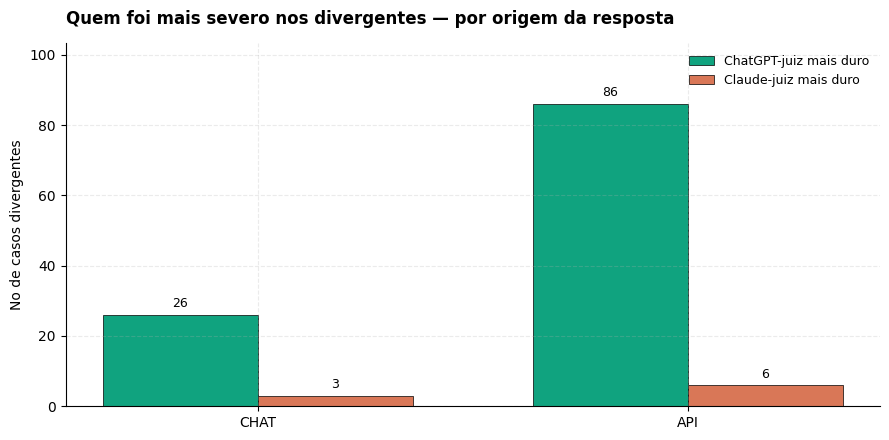


Media (Opus - GPT) — positivo = Claude-juiz mais generoso (Opus deu nota maior):
        media Opus-GPT
origem                
chat             0.397
api              0.435


In [8]:
sev = []
for org in ["chat","api"]:
    sub = df[(df["origem"] == org) & (~df["convergencia"])].copy()
    if len(sub) == 0:
        continue
    sub["dif_opus_gpt"] = sub["avaliacao_opus"] - sub["avaliacao_gpt"]
    mais_gpt  = (sub["dif_opus_gpt"] > 0).sum()   # Opus deu nota maior -> GPT mais duro
    mais_opus = (sub["dif_opus_gpt"] < 0).sum()   # GPT  deu nota maior -> Opus mais duro
    sev.append({"origem": org,
                "ChatGPT-juiz mais duro": mais_gpt,
                "Claude-juiz mais duro":  mais_opus,
                "media Opus-GPT": sub["dif_opus_gpt"].mean()})
sev_df = pd.DataFrame(sev).set_index("origem")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(sev_df))
w = 0.36
b1 = ax.bar(x - w/2, sev_df["ChatGPT-juiz mais duro"].values, w,
            label="ChatGPT-juiz mais duro", color=PALETA_AVALIADOR["gpt"],
            edgecolor="black", linewidth=0.5)
b2 = ax.bar(x + w/2, sev_df["Claude-juiz mais duro"].values, w,
            label="Claude-juiz mais duro", color=PALETA_AVALIADOR["opus"],
            edgecolor="black", linewidth=0.5)
ymax_obs = max(sev_df["ChatGPT-juiz mais duro"].max(), sev_df["Claude-juiz mais duro"].max())
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + max(ymax_obs*0.015, 0.3),
                    f"{int(h)}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([o.upper() for o in sev_df.index])
ax.set_ylabel("No de casos divergentes")
ax.set_title("Quem foi mais severo nos divergentes — por origem da resposta")
ax.set_ylim(0, max(1, ymax_obs) * 1.20)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("\nMedia (Opus - GPT) — positivo = Claude-juiz mais generoso (Opus deu nota maior):")
print(sev_df[["media Opus-GPT"]].round(3).to_string())

**O sinal a procurar:** a relação de severidade entre os juízes **inverte** ou **se mantém** entre Chat e API?

- **Mantém** → viés sistemático (um juiz é mais duro independentemente do canal).
- **Inverte** → viés condicional ao formato. A escolha do juiz precisa considerar a origem das respostas que ele vai avaliar.

## 6. Extra — quem o humano segue por modelo da resposta

O `avaliacao_humana` só está preenchido com nota pertinente nos 121 casos divergentes (no resto vem `"nao pertinente"`), então **não dá para usar essa coluna como ground truth no agregado completo**. O que dá para fazer com ela: refinar a seção 5.1, mostrando em quem o humano confiou quebrando **por modelo da resposta avaliada** dentro de cada origem. Isso responde a uma pergunta operacional: *o viés do humano em favor de um juiz depende do modelo cujas respostas estão sendo avaliadas?*

In [9]:
div = df[~df["convergencia"]].copy()
div_num = div[div["avaliacao_humana"].apply(lambda v: isinstance(v, (int, float, np.integer, np.floating)))].copy()
div_num["av_humana_num"] = pd.to_numeric(div_num["avaliacao_humana"], errors="coerce")
div_num = div_num[div_num["av_humana_num"].notna()].copy()

div_num["confiou_em"] = np.where(div_num["av_humana_num"] == div_num["avaliacao_gpt"], "ChatGPT-juiz",
                          np.where(div_num["av_humana_num"] == div_num["avaliacao_opus"], "Claude-juiz", "Nenhum"))

ct = (div_num.groupby(["origem","modelo","confiou_em"]).size()
              .unstack(fill_value=0)
              .reindex(columns=["ChatGPT-juiz","Claude-juiz","Nenhum"], fill_value=0))
ct["total"] = ct.sum(axis=1)
ct = ct.sort_values(["origem","total"], ascending=[True, False])
print("Voto do humano por (origem, modelo avaliado):")
print()
print(ct.to_string())

# Heatmap simples: % de vezes que humano confiou no ChatGPT-juiz, por modelo
pct_gpt = (div_num.assign(seguiu_gpt = (div_num["confiou_em"] == "ChatGPT-juiz").astype(int))
                  .groupby(["origem","modelo"])["seguiu_gpt"].mean()
                  .unstack(level="origem"))
print()
print("% de vezes que o humano concordou com o ChatGPT-juiz (vs Claude-juiz), por modelo:")
print((pct_gpt*100).round(1).to_string())

Voto do humano por (origem, modelo avaliado):

confiou_em                ChatGPT-juiz  Claude-juiz  Nenhum  total
origem modelo                                                     
api    claude-haiku-4-5             14            3       0     17
       gpt-5.4-mini                 11            5       0     16
       gpt-4o-mini                  11            4       0     15
       deepseek-v4-pro               7            6       0     13
       claude-opus-4-7               6            2       0      8
       claude-sonnet-4-6             6            2       0      8
       deepseek-v4-flash             6            2       0      8
       gpt-5.5                       1            4       0      5
       gpt-5.4                       1            1       0      2
chat   std_claude                   14            4       0     18
       std_chatgpt                   9            2       0     11

% de vezes que o humano concordou com o ChatGPT-juiz (vs Claude-juiz), por modelo

**Como ler:** se um modelo aparece com taxa muito diferente de 50%, significa que o humano teve uma preferência clara por um dos juízes ao avaliar respostas daquele modelo específico. Taxas próximas de 100% no ChatGPT-juiz indicam que, para aquele modelo, o ChatGPT-juiz foi muito mais aderente à arbitragem humana.

**Cuidado com tamanhos pequenos:** as `n_divergentes` por (origem × modelo) caem rápido. Lê esses percentuais junto da coluna `total` da tabela — se `total` é 3 ou 4, a porcentagem é apenas indicativa.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


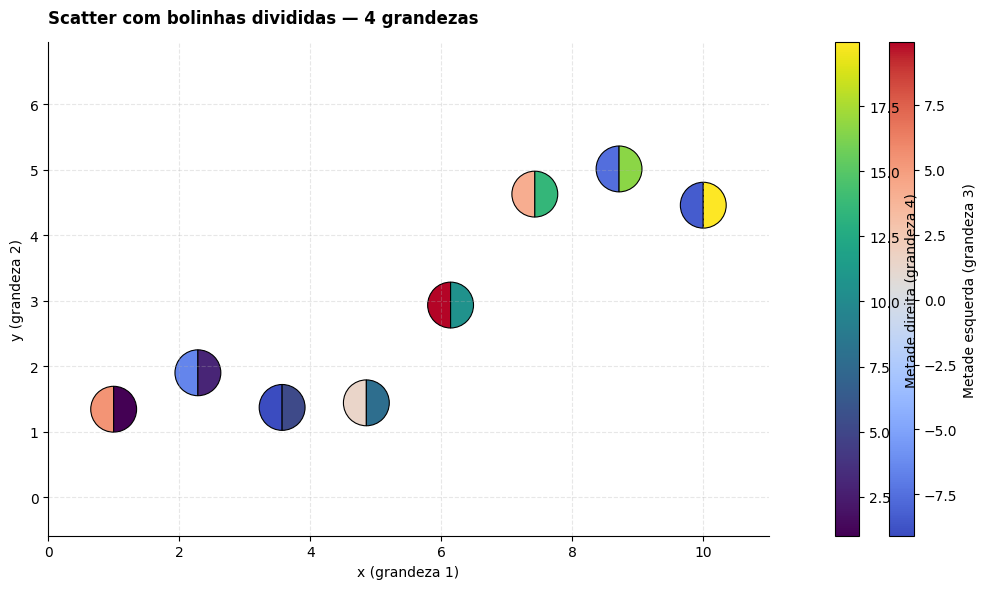

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ---- Dados de exemplo (4 grandezas variando com x) ----
np.random.seed(0)
n = 8
x = np.linspace(1, 10, n)          # grandeza 1: posição x
y = np.sin(x) + 0.5 * x            # grandeza 2: posição y
val_esq = np.cos(x) * 10           # grandeza 3: cor da metade esquerda
val_dir = x**1.3                   # grandeza 4: cor da metade direita

# ---- Configuração do plot ----
fig, ax = plt.subplots(figsize=(10, 6))

raio = 0.35  # raio das bolinhas (em unidades de dados)

# Escalas de cor independentes para cada metade
cmap_esq = plt.cm.coolwarm
cmap_dir = plt.cm.viridis
norm_esq = Normalize(vmin=val_esq.min(), vmax=val_esq.max())
norm_dir = Normalize(vmin=val_dir.min(), vmax=val_dir.max())

# Desenha cada bolinha como duas wedges (metades)
for xi, yi, ve, vd in zip(x, y, val_esq, val_dir):
    w_esq = Wedge((xi, yi), raio, 90, 270,
                  facecolor=cmap_esq(norm_esq(ve)),
                  edgecolor='black', linewidth=0.8)
    w_dir = Wedge((xi, yi), raio, -90, 90,
                  facecolor=cmap_dir(norm_dir(vd)),
                  edgecolor='black', linewidth=0.8)
    ax.add_patch(w_esq)
    ax.add_patch(w_dir)

ax.set_xlim(x.min() - 1, x.max() + 1)
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('x (grandeza 1)')
ax.set_ylabel('y (grandeza 2)')
ax.set_title('Scatter com bolinhas divididas — 4 grandezas')
ax.grid(True, alpha=0.3)

# Barras de cor para cada metade
sm_esq = ScalarMappable(norm=norm_esq, cmap=cmap_esq); sm_esq.set_array([])
sm_dir = ScalarMappable(norm=norm_dir, cmap=cmap_dir); sm_dir.set_array([])
cbar1 = fig.colorbar(sm_esq, ax=ax, pad=0.02, fraction=0.045)
cbar1.set_label('Metade esquerda (grandeza 3)')
cbar2 = fig.colorbar(sm_dir, ax=ax, pad=0.08, fraction=0.045)
cbar2.set_label('Metade direita (grandeza 4)')

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


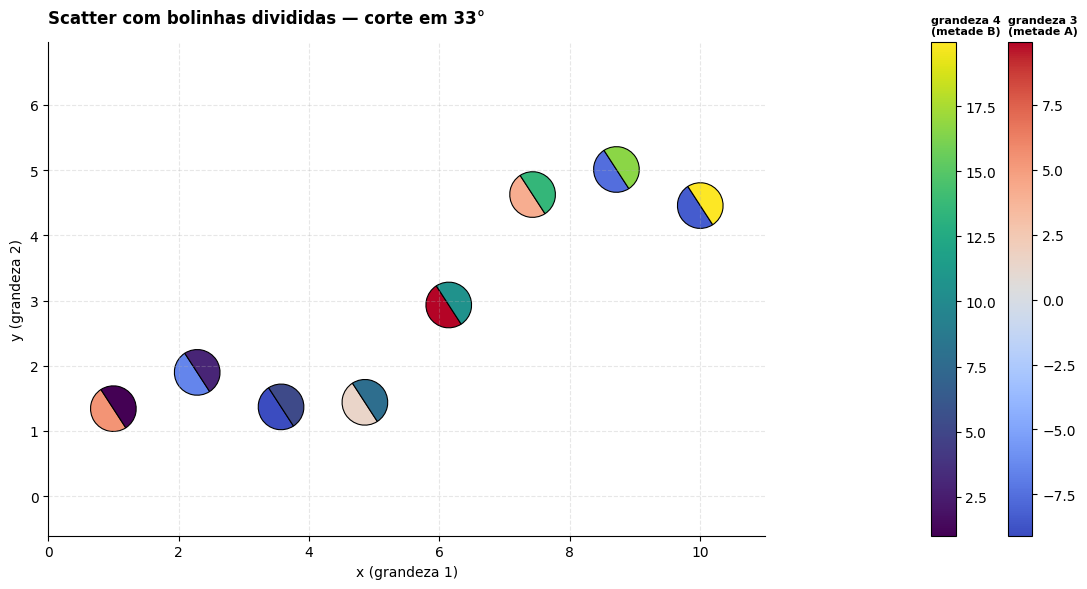

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ---- Dados de exemplo (4 grandezas variando com x) ----
np.random.seed(0)
n = 8
x = np.linspace(1, 10, n)          # grandeza 1: posição x
y = np.sin(x) + 0.5 * x            # grandeza 2: posição y
val_a = np.cos(x) * 10             # grandeza 3: cor de uma metade
val_b = x**1.3                     # grandeza 4: cor da outra metade

# ---- Parâmetros visuais ----
raio = 0.35
angulo_graus = 33   # 0 = corte vertical (esq/dir); 90 = corte horizontal (cima/baixo);
                   # 45 = corte diagonal; aceita qualquer valor

cmap_a = plt.cm.coolwarm
cmap_b = plt.cm.viridis

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 6))

norm_a = Normalize(vmin=val_a.min(), vmax=val_a.max())
norm_b = Normalize(vmin=val_b.min(), vmax=val_b.max())

# A linha de corte é perpendicular a `angulo_graus`.
# As wedges são definidas pelos seus ângulos de início/fim no círculo.
theta1_a = angulo_graus + 90
theta2_a = angulo_graus + 270
theta1_b = angulo_graus - 90
theta2_b = angulo_graus + 90

for xi, yi, va, vb in zip(x, y, val_a, val_b):
    ax.add_patch(Wedge((xi, yi), raio, theta1_a, theta2_a,
                       facecolor=cmap_a(norm_a(va)),
                       edgecolor='black', linewidth=0.8))
    ax.add_patch(Wedge((xi, yi), raio, theta1_b, theta2_b,
                       facecolor=cmap_b(norm_b(vb)),
                       edgecolor='black', linewidth=0.8))

ax.set_xlim(x.min() - 1, x.max() + 1)
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('x (grandeza 1)')
ax.set_ylabel('y (grandeza 2)')
ax.set_title(f'Scatter com bolinhas divididas — corte em {angulo_graus}°')
ax.grid(True, alpha=0.3)

# ---- Colorbars com títulos no topo (não sobrepõem as barras) ----
sm_a = ScalarMappable(norm=norm_a, cmap=cmap_a); sm_a.set_array([])
sm_b = ScalarMappable(norm=norm_b, cmap=cmap_b); sm_b.set_array([])

cbar_a = fig.colorbar(sm_a, ax=ax, pad=0.04, fraction=0.04)
cbar_a.ax.set_title('grandeza 3\n(metade A)', fontsize=8, pad=6)

cbar_b = fig.colorbar(sm_b, ax=ax, pad=0.18, fraction=0.04)
cbar_b.ax.set_title('grandeza 4\n(metade B)', fontsize=8, pad=6)

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


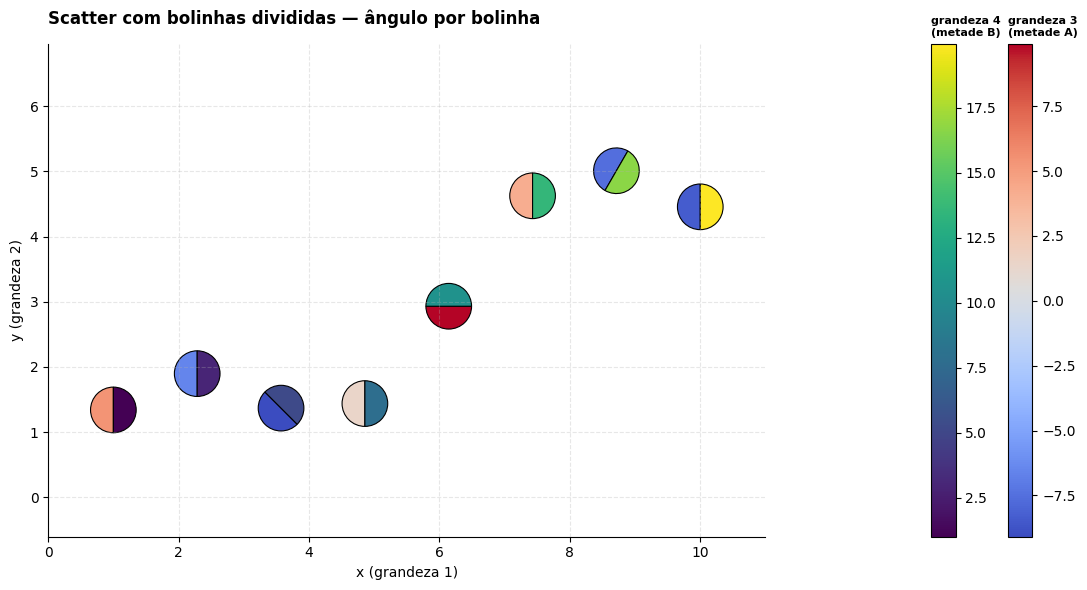

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ---- Dados de exemplo (4 grandezas variando com x) ----
np.random.seed(0)
n = 8
x = np.linspace(1, 10, n)          # grandeza 1: posição x
y = np.sin(x) + 0.5 * x            # grandeza 2: posição y
val_a = np.cos(x) * 10             # grandeza 3: cor de uma metade
val_b = x**1.3                     # grandeza 4: cor da outra metade

# ---- Parâmetros visuais ----
raio = 0.35

# Ângulo de corte: pode ser escalar (vale pra todas) OU lista/array de tamanho n.
angulo_graus = [0]*n
angulo_graus[2] = 45
angulo_graus[4] = 90
angulo_graus[6] = -30
# (Se quiser todos iguais, basta: angulo_graus = 0)

cmap_a = plt.cm.coolwarm
cmap_b = plt.cm.viridis

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 6))

norm_a = Normalize(vmin=val_a.min(), vmax=val_a.max())
norm_b = Normalize(vmin=val_b.min(), vmax=val_b.max())

# Normaliza o parâmetro de ângulo para um array de tamanho n
angulos = np.broadcast_to(np.asarray(angulo_graus), (n,))

for xi, yi, va, vb, ang in zip(x, y, val_a, val_b, angulos):
    ax.add_patch(Wedge((xi, yi), raio, ang + 90, ang + 270,
                       facecolor=cmap_a(norm_a(va)),
                       edgecolor='black', linewidth=0.8))
    ax.add_patch(Wedge((xi, yi), raio, ang - 90, ang + 90,
                       facecolor=cmap_b(norm_b(vb)),
                       edgecolor='black', linewidth=0.8))

ax.set_xlim(x.min() - 1, x.max() + 1)
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('x (grandeza 1)')
ax.set_ylabel('y (grandeza 2)')
ax.set_title('Scatter com bolinhas divididas — ângulo por bolinha')
ax.grid(True, alpha=0.3)

# Colorbars
sm_a = ScalarMappable(norm=norm_a, cmap=cmap_a); sm_a.set_array([])
sm_b = ScalarMappable(norm=norm_b, cmap=cmap_b); sm_b.set_array([])

cbar_a = fig.colorbar(sm_a, ax=ax, pad=0.04, fraction=0.04)
cbar_a.ax.set_title('grandeza 3\n(metade A)', fontsize=8, pad=6)

cbar_b = fig.colorbar(sm_b, ax=ax, pad=0.18, fraction=0.04)
cbar_b.ax.set_title('grandeza 4\n(metade B)', fontsize=8, pad=6)

plt.tight_layout()
plt.show()